# Skello — Support Analytics

**Case study Data Analyst Stagiaire** · Modèle de données et reporting hebdomadaire pour l'équipe Support, à partir des données Intercom.

### Plan du notebook
1. Setup
2. Chargement RAW
3. Construction des modèles (staging → intermediate → marts)
4. Tests automatisés
5. Dashboard hebdomadaire
6. **Insights business** (trouvailles dans les données)
7. **Analyse FRT ↔ CSAT** (à quel point le délai impacte la satisfaction)
8. Exploration libre

## 1. Installation & imports

In [1]:
# %pip install duckdb pandas matplotlib --quiet

from pathlib import Path
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

pd.options.display.max_columns = 50
pd.options.display.width = 200
plt.rcParams.update({"figure.figsize": (10, 4), "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "font.size": 10})

print(f"DuckDB {duckdb.__version__} · pandas {pd.__version__}")

DuckDB 1.5.2 · pandas 3.0.2


## 2. Connexion DuckDB + chargement RAW

In [2]:
DB_PATH = Path("../outputs/skello.duckdb")
DB_PATH.parent.mkdir(parents=True, exist_ok=True)
if DB_PATH.exists():
    DB_PATH.unlink()
con = duckdb.connect(str(DB_PATH))

def q(sql):
    return con.execute(sql).fetchdf()

for s in ("raw", "staging", "intermediate", "marts"):
    con.execute(f"CREATE SCHEMA IF NOT EXISTS {s}")

CONV  = Path("../data/raw/CONVERSATIONS.csv")
PARTS = Path("../data/raw/CONVERSATION_PARTS.csv")
assert CONV.exists() and PARTS.exists(), f"CSV introuvables dans {CONV.parent.resolve()}"

con.execute(f"CREATE OR REPLACE TABLE raw.conversations      AS SELECT * FROM read_csv_auto('{CONV.as_posix()}',  sample_size=50000)")
con.execute(f"CREATE OR REPLACE TABLE raw.conversation_parts AS SELECT * FROM read_csv_auto('{PARTS.as_posix()}', sample_size=50000)")

q("""
SELECT 'raw.conversations'      AS table_name, COUNT(*) AS n_rows FROM raw.conversations
UNION ALL
SELECT 'raw.conversation_parts', COUNT(*)                          FROM raw.conversation_parts
""")

,table_name,n_rows
0,raw.conversations,11799
1,raw.conversation_parts,252653


## 3. Construction des 9 modèles

In [3]:
MODELS = [
    ('staging.stg_intercom__conversations', r"""
-- =============================================================================
-- stg_intercom__conversations  (DuckDB)
-- 1 ligne = 1 conversation, JSON parsé, timestamps typés, dédoublonné.
-- =============================================================================

CREATE OR REPLACE TABLE staging.stg_intercom__conversations AS

WITH deduplicated AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY ID
            ORDER BY UPDATED_AT DESC, _SDC_SEQUENCE DESC
        ) AS rn
    FROM raw.conversations
)

SELECT
    ID                                                              AS conversation_id,

    -- Timestamps : on enlève le " Z" final puis on parse avec millisecondes
    strptime(REPLACE(CREATED_AT,    ' Z', ''), '%Y-%m-%d %H:%M:%S.%g')   AS created_at,
    strptime(REPLACE(UPDATED_AT,    ' Z', ''), '%Y-%m-%d %H:%M:%S.%g')   AS updated_at,
    try_strptime(REPLACE(CAST(WAITING_SINCE AS VARCHAR),  ' Z', ''), '%Y-%m-%d %H:%M:%S.%g') AS waiting_since,
    try_strptime(REPLACE(CAST(SNOOZED_UNTIL AS VARCHAR),  ' Z', ''), '%Y-%m-%d %H:%M:%S.%g') AS snoozed_until,

    STATE                                                           AS state,
    OPEN                                                            AS is_open,
    READ                                                            AS is_read,
    (PRIORITY = 'priority')                                         AS is_priority,

    -- Assignee final (peut différer des assignations intermédiaires, cf. int_conversation_assignments)
    json_extract_string(ASSIGNEE, '$.id')                           AS final_assignee_id,
    json_extract_string(ASSIGNEE, '$.type')                         AS final_assignee_type,

    -- CSAT rating
    TRY_CAST(json_extract_string(CONVERSATION_RATING, '$.rating') AS INTEGER) AS csat_rating,
    json_extract_string(CONVERSATION_RATING, '$.remark')            AS csat_remark,
    try_strptime(
        json_extract_string(CONVERSATION_RATING, '$.created_at'),
        '%Y-%m-%dT%H:%M:%S%z'
    )                                                               AS csat_created_at,
    json_extract_string(CONVERSATION_RATING, '$.teammate.id')       AS csat_rated_teammate_id,

    -- Tags : liste de noms (LIST<VARCHAR>) prête à UNNEST
    CASE
        WHEN TAGS IS NULL THEN NULL
        ELSE list_transform(
                CAST(TAGS AS JSON)::JSON[],
                x -> json_extract_string(x, '$.name')
             )
    END                                                             AS tag_names

FROM deduplicated
WHERE rn = 1
  AND ID IS NOT NULL;  -- 1 ligne avec ID NULL dans la source, exclue
"""),
    ('staging.stg_intercom__conversation_parts', r"""
-- =============================================================================
-- stg_intercom__conversation_parts  (DuckDB)
-- 1 ligne = 1 event sur une conversation.
-- Important : ASSIGNED_TO est en réalité un objet JSON {id, type}, pas un id brut.
-- =============================================================================

CREATE OR REPLACE TABLE staging.stg_intercom__conversation_parts AS

WITH deduplicated AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY ID
            ORDER BY UPDATED_AT DESC, _SDC_SEQUENCE DESC
        ) AS rn
    FROM raw.conversation_parts
)

SELECT
    ID                                                                AS part_id,
    CONVERSATION_ID                                                   AS conversation_id,

    strptime(REPLACE(CREATED_AT,                 ' Z', ''), '%Y-%m-%d %H:%M:%S.%g') AS created_at,
    strptime(REPLACE(UPDATED_AT,                 ' Z', ''), '%Y-%m-%d %H:%M:%S.%g') AS updated_at,
    try_strptime(REPLACE(NOTIFIED_AT,            ' Z', ''), '%Y-%m-%d %H:%M:%S.%g') AS notified_at,
    strptime(REPLACE(CONVERSATION_CREATED_AT,    ' Z', ''), '%Y-%m-%d %H:%M:%S.%g') AS conversation_created_at,

    PART_GROUP                                                        AS part_group,

    -- Auteur : id + type
    json_extract_string(AUTHOR, '$.id')                               AS author_id,
    json_extract_string(AUTHOR, '$.type')                             AS author_type,
    (json_extract_string(AUTHOR, '$.type') = 'bot')                   AS is_bot,
    (json_extract_string(AUTHOR, '$.type') = 'admin')                 AS is_admin,
    (json_extract_string(AUTHOR, '$.type') = 'user')                  AS is_customer,

    -- Cible d'assignation : attention, ce champ est sérialisé au format
    -- Python dict (apostrophes simples, None au lieu de null), pas en JSON.
    -- On extrait par regex. Ex : "{'type': 'admin', 'id': '5217337'}"
    NULLIF(regexp_extract(ASSIGNED_TO, '''id'':\s*''([^'']+)''',   1), '') AS assigned_to_id,
    NULLIF(regexp_extract(ASSIGNED_TO, '''type'':\s*''([^'']+)''', 1), '') AS assigned_to_type,

    (PART_GROUP = 'Message')                                          AS is_message,
    (PART_GROUP = 'Assignment')                                       AS is_assignment,
    (PART_GROUP = 'Close')                                            AS is_close,
    (PART_GROUP = 'Snooze')                                           AS is_snooze

FROM deduplicated
WHERE rn = 1;
"""),
    ('intermediate.int_conversation_first_response', r"""
/* =============================================================================
   int_conversation_first_response  (DuckDB)
   -----------------------------------------------------------------------------
   Objet : calcule le First Response Time (FRT) — délai entre la création
           de la conversation et le premier message d'un admin HUMAIN
           (bots exclus).
   Granularité : 1 ligne = 1 conversation

   Cas particulier des conversations OUTBOUND :
     ~2% des conversations ont un premier message admin antérieur à la
     création de la conversation (FRT négatif). Il s'agit de conversations
     initiées par Skello (onboarding, relance, notification…), pas par le
     client. Pour ces conv, le KPI "1ʳᵉ réponse < 5 min" n'a pas de sens
     car le client n'a pas encore écrit. On les flag `is_outbound = TRUE`
     et on les exclut des KPI de FRT dans les marts.
   ============================================================================= */

CREATE OR REPLACE TABLE intermediate.int_conversation_first_response AS

WITH admin_messages AS (
    SELECT
        conversation_id,
        author_id,
        created_at
    FROM staging.stg_intercom__conversation_parts
    WHERE is_message = TRUE
      AND is_admin   = TRUE
      AND is_bot     = FALSE
),

first_admin_reply AS (
    SELECT
        conversation_id,
        MIN(created_at)                                   AS first_admin_reply_at,
        arg_min(author_id, created_at)                    AS first_responder_admin_id
    FROM admin_messages
    GROUP BY conversation_id
),

joined AS (
    SELECT
        c.conversation_id,
        c.created_at                                                              AS conversation_created_at,
        fr.first_admin_reply_at,
        fr.first_responder_admin_id,
        CAST(date_diff('second', c.created_at, fr.first_admin_reply_at) AS BIGINT) AS frt_seconds_raw,
        -- Conv où admin a parlé en premier (outbound) : FRT négatif
        COALESCE(fr.first_admin_reply_at < c.created_at, FALSE)                   AS is_outbound
    FROM staging.stg_intercom__conversations c
    LEFT JOIN first_admin_reply fr USING (conversation_id)
)

SELECT
    conversation_id,
    conversation_created_at,
    first_admin_reply_at,
    first_responder_admin_id,
    is_outbound,
    -- frt_seconds nullifié pour les outbound (KPI non pertinent)
    CASE WHEN is_outbound THEN NULL ELSE frt_seconds_raw END        AS frt_seconds,
    CASE WHEN is_outbound THEN NULL ELSE frt_seconds_raw / 60.0 END AS frt_minutes,
    CASE
        WHEN is_outbound                          THEN 'outbound'
        WHEN frt_seconds_raw IS NULL              THEN 'no_admin_reply'
        WHEN frt_seconds_raw <  60                THEN 'under_1_min'
        WHEN frt_seconds_raw <  5 * 60            THEN 'under_5_min'
        WHEN frt_seconds_raw < 30 * 60            THEN 'under_30_min'
        WHEN frt_seconds_raw <  2 * 60 * 60       THEN 'under_2_hours'
        WHEN frt_seconds_raw < 24 * 60 * 60       THEN 'under_1_day'
        ELSE 'over_1_day'
    END                                                             AS frt_bucket,
    -- Flag direct pour le KPI métier (les outbound sont exclus)
    CASE
        WHEN is_outbound             THEN FALSE
        WHEN frt_seconds_raw IS NULL THEN FALSE
        ELSE (frt_seconds_raw < 5 * 60)
    END                                                             AS is_replied_under_5min
FROM joined;
"""),
    ('intermediate.int_conversation_assignments', r"""
-- =============================================================================
-- int_conversation_assignments  (DuckDB)
-- Historique des (ré)assignations d'une conv. Permet d'identifier les conv
-- ayant été traitées par la team Support, même si l'assignee final est ailleurs.
-- =============================================================================

CREATE OR REPLACE TABLE intermediate.int_conversation_assignments AS

WITH assignment_events AS (
    SELECT
        conversation_id,
        part_id,
        created_at                                AS assigned_at,
        assigned_to_id,
        assigned_to_type,
        -- Les 4 IDs de la team Support (hard-codés ici par souci de lisibilité.
        -- En prod : JOIN dim_support_agents.)
        (assigned_to_id IN ('5217337', '5391224', '5440474', '5300290')) AS is_support_assignment
    FROM staging.stg_intercom__conversation_parts
    WHERE is_assignment = TRUE
      AND assigned_to_id IS NOT NULL
),

support_assignments AS (
    SELECT * FROM assignment_events WHERE is_support_assignment
),

aggregated AS (
    SELECT
        conversation_id,
        COUNT(DISTINCT part_id)                                       AS nb_assignments,
        COUNT(DISTINCT assigned_to_id)                                AS nb_distinct_assignees,
        SUM(CASE WHEN is_support_assignment THEN 1 ELSE 0 END)        AS nb_support_assignments,
        bool_or(is_support_assignment)                                AS is_handled_by_support
    FROM assignment_events
    GROUP BY conversation_id
),

first_last_support AS (
    SELECT
        conversation_id,
        arg_min(assigned_to_id, assigned_at)                          AS first_support_assignee_id,
        MIN(assigned_at)                                              AS first_support_assigned_at,
        arg_max(assigned_to_id, assigned_at)                          AS last_support_assignee_id,
        MAX(assigned_at)                                              AS last_support_assigned_at
    FROM support_assignments
    GROUP BY conversation_id
)

SELECT
    a.conversation_id,
    a.nb_assignments,
    a.nb_distinct_assignees,
    a.nb_support_assignments,
    a.is_handled_by_support,
    f.first_support_assignee_id,
    f.first_support_assigned_at,
    f.last_support_assignee_id,
    f.last_support_assigned_at
FROM aggregated a
LEFT JOIN first_last_support f USING (conversation_id);
"""),
    ('intermediate.int_admin_messages', r"""
-- =============================================================================
-- int_admin_messages  (DuckDB)
-- 1 ligne = 1 message d'admin humain. Sert aux analyses de charge horaire,
-- heatmap d'activité, et performance individuelle.
-- =============================================================================

CREATE OR REPLACE TABLE intermediate.int_admin_messages AS

SELECT
    part_id,
    conversation_id,
    author_id                                       AS admin_id,
    created_at                                      AS sent_at,
    CAST(created_at AS DATE)                        AS sent_date,
    EXTRACT(HOUR    FROM created_at)                AS sent_hour,
    -- isodow : 1=lundi ... 7=dimanche (norme ISO 8601)
    EXTRACT(isodow  FROM created_at)                AS sent_day_of_week_iso,
    dayname(created_at)                             AS sent_day_name,
    EXTRACT(isoyear FROM created_at)                AS sent_year_iso,
    EXTRACT(week    FROM created_at)                AS sent_week_iso,
    -- Date du lundi de la semaine (pour groupages hebdo)
    date_trunc('week', created_at)                  AS sent_week_start
FROM staging.stg_intercom__conversation_parts
WHERE is_message = TRUE
  AND is_admin   = TRUE
  AND is_bot     = FALSE;
"""),
    ('marts.dim_date', r"""
-- =============================================================================
-- dim_date  (DuckDB)
-- Table calendrier sur 2021-2027.
-- =============================================================================

CREATE OR REPLACE TABLE marts.dim_date AS

WITH date_spine AS (
    SELECT DATE '2021-01-01' + INTERVAL (i) DAY AS date_day
    FROM range(0, 2557) t(i)             -- ~7 ans
)

SELECT
    date_day,
    EXTRACT(year   FROM date_day)                           AS year_num,
    EXTRACT(month  FROM date_day)                           AS month_num,
    EXTRACT(day    FROM date_day)                           AS day_of_month,
    EXTRACT(isodow FROM date_day)                           AS day_of_week_iso,    -- 1=lundi
    dayname(date_day)                                       AS day_name,
    EXTRACT(isoyear FROM date_day)                          AS year_iso,
    EXTRACT(week    FROM date_day)                          AS week_iso,
    date_trunc('week',  date_day)                           AS week_start_date,    -- lundi de la semaine
    date_trunc('month', date_day)                           AS month_start_date,
    (EXTRACT(isodow FROM date_day) IN (6, 7))               AS is_weekend
FROM date_spine
WHERE date_day <= DATE '2027-12-31';
"""),
    ('marts.dim_support_agents', r"""
-- =============================================================================
-- dim_support_agents  (DuckDB)
-- Référentiel statique des 4 membres de la team Support.
-- =============================================================================

CREATE OR REPLACE TABLE marts.dim_support_agents AS
SELECT * FROM (
    VALUES
        ('5217337', 'Héloïse', 'Support', TRUE),
        ('5391224', 'Justine', 'Support', TRUE),
        ('5440474', 'Patrick', 'Support', TRUE),
        ('5300290', 'Raphaël', 'Support', TRUE)
) AS t(admin_id, first_name, team, is_active);
"""),
    ('marts.fct_conversations', r"""
-- =============================================================================
-- fct_conversations  (DuckDB)
-- Table de faits PRINCIPALE : 1 ligne = 1 conversation, enrichie de toutes
-- les métriques nécessaires au reporting. C'est la table que la BI requête
-- en priorité (80% des questions de Lorette s'écrivent en SELECT ... GROUP BY).
-- =============================================================================

CREATE OR REPLACE TABLE marts.fct_conversations AS

WITH message_counts AS (
    SELECT
        conversation_id,
        SUM(CASE WHEN is_admin    AND NOT is_bot THEN 1 ELSE 0 END)   AS nb_admin_messages,
        SUM(CASE WHEN is_customer                THEN 1 ELSE 0 END)   AS nb_customer_messages,
        COUNT(*)                                                       AS nb_messages_total
    FROM staging.stg_intercom__conversation_parts
    WHERE is_message = TRUE
    GROUP BY conversation_id
),

close_event AS (
    SELECT
        conversation_id,
        MAX(created_at)                                                AS closed_at,
        arg_max(author_id, created_at)                                 AS closed_by_admin_id
    FROM staging.stg_intercom__conversation_parts
    WHERE is_close = TRUE
    GROUP BY conversation_id
)

SELECT
    c.conversation_id,

    -- Dimensions temporelles
    c.created_at                                                       AS conversation_created_at,
    CAST(c.created_at AS DATE)                                         AS conversation_created_date,
    date_trunc('week', c.created_at)                                   AS conversation_created_week,
    close_event.closed_at,
    date_diff('minute', c.created_at, close_event.closed_at)           AS resolution_minutes,

    -- État
    c.state,
    c.is_open,
    c.is_priority,

    -- Assignations
    c.final_assignee_id,
    c.final_assignee_type,
    asg.first_support_assignee_id,
    asg.last_support_assignee_id,
    COALESCE(asg.is_handled_by_support, FALSE)                         AS is_handled_by_support,
    COALESCE(asg.nb_assignments, 0)                                    AS nb_assignments,

    -- First Response Time
    frt.first_admin_reply_at,
    frt.first_responder_admin_id,
    frt.frt_seconds,
    frt.frt_minutes,
    frt.frt_bucket,
    COALESCE(frt.is_replied_under_5min, FALSE)                         AS is_replied_under_5min,
    COALESCE(frt.is_outbound, FALSE)                                   AS is_outbound,

    -- Volume de messages
    COALESCE(mc.nb_admin_messages,    0)                               AS nb_admin_messages,
    COALESCE(mc.nb_customer_messages, 0)                               AS nb_customer_messages,
    COALESCE(mc.nb_messages_total,    0)                               AS nb_messages_total,
    (COALESCE(mc.nb_admin_messages, 0) = 1)                            AS is_one_touch,

    -- CSAT
    c.csat_rating,
    c.csat_remark,
    c.csat_created_at,
    c.csat_rated_teammate_id,
    (c.csat_rating IS NOT NULL)                                        AS has_csat,
    (c.csat_rating >= 4)                                               AS is_csat_positive,
    (c.csat_rating <= 2)                                               AS is_csat_negative,

    -- Tags
    c.tag_names

FROM staging.stg_intercom__conversations               c
LEFT JOIN intermediate.int_conversation_first_response  frt USING (conversation_id)
LEFT JOIN intermediate.int_conversation_assignments     asg USING (conversation_id)
LEFT JOIN message_counts                                 mc USING (conversation_id)
LEFT JOIN close_event                                       USING (conversation_id);
"""),
    ('marts.fct_agent_daily_activity', r"""
-- =============================================================================
-- fct_agent_daily_activity  (DuckDB)
-- 1 ligne = 1 agent × 1 jour. Sert au tableau de comparaison hebdo par agent
-- et à la heatmap d'activité.
-- =============================================================================

CREATE OR REPLACE TABLE marts.fct_agent_daily_activity AS

WITH spine AS (
    SELECT
        a.admin_id,
        a.first_name,
        d.date_day,
        d.week_start_date,
        d.day_of_week_iso,
        d.day_name
    FROM marts.dim_support_agents a
    CROSS JOIN marts.dim_date d
    WHERE d.date_day BETWEEN DATE '2021-10-01' AND CURRENT_DATE
      AND a.is_active = TRUE
),

daily_messages AS (
    SELECT
        admin_id,
        sent_date,
        COUNT(*)                                AS nb_messages_sent,
        COUNT(DISTINCT conversation_id)         AS nb_conversations_touched
    FROM intermediate.int_admin_messages
    GROUP BY admin_id, sent_date
),

daily_first_response AS (
    SELECT
        f.first_responder_admin_id              AS admin_id,
        CAST(f.first_admin_reply_at AS DATE)    AS response_date,
        COUNT(*)                                AS nb_conversations_first_replied,
        AVG(f.frt_minutes)                      AS avg_frt_minutes,
        MEDIAN(f.frt_minutes)                   AS median_frt_minutes,
        AVG(CASE WHEN f.is_replied_under_5min THEN 1.0 ELSE 0.0 END) * 100 AS pct_under_5min
    FROM intermediate.int_conversation_first_response f
    WHERE f.first_responder_admin_id IS NOT NULL
    GROUP BY 1, 2
),

daily_csat AS (
    SELECT
        csat_rated_teammate_id                  AS admin_id,
        CAST(csat_created_at AS DATE)           AS csat_date,
        COUNT(*)                                AS nb_csat_received,
        AVG(csat_rating)                        AS avg_csat,
        AVG(CASE WHEN is_csat_positive THEN 1.0 ELSE 0.0 END) * 100 AS pct_csat_positive
    FROM marts.fct_conversations
    WHERE has_csat = TRUE
      AND csat_rated_teammate_id IS NOT NULL
    GROUP BY 1, 2
)

SELECT
    s.admin_id,
    s.first_name,
    s.date_day,
    s.week_start_date,
    s.day_of_week_iso,
    s.day_name,

    COALESCE(dm.nb_messages_sent,                0)      AS nb_messages_sent,
    COALESCE(dm.nb_conversations_touched,        0)      AS nb_conversations_touched,

    COALESCE(dfr.nb_conversations_first_replied, 0)      AS nb_conversations_first_replied,
    dfr.avg_frt_minutes,
    dfr.median_frt_minutes,
    dfr.pct_under_5min,

    COALESCE(dc.nb_csat_received,                0)      AS nb_csat_received,
    dc.avg_csat,
    dc.pct_csat_positive

FROM spine s
LEFT JOIN daily_messages       dm  ON dm.admin_id  = s.admin_id AND dm.sent_date      = s.date_day
LEFT JOIN daily_first_response dfr ON dfr.admin_id = s.admin_id AND dfr.response_date = s.date_day
LEFT JOIN daily_csat           dc  ON dc.admin_id  = s.admin_id AND dc.csat_date      = s.date_day;
"""),
]

for name, sql in MODELS:
    con.execute(sql)
    print(f'  ✓ {name}')

print('\n✅ Tous les modèles construits')

  ✓ staging.stg_intercom__conversations


  ✓ staging.stg_intercom__conversation_parts
  ✓ intermediate.int_conversation_first_response
  ✓ intermediate.int_conversation_assignments
  ✓ intermediate.int_admin_messages
  ✓ marts.dim_date
  ✓ marts.dim_support_agents
  ✓ marts.fct_conversations


  ✓ marts.fct_agent_daily_activity

✅ Tous les modèles construits


## 4. Tests automatisés

Suite de **11 tests** style dbt : intégrité (PK uniques), métier (CSAT dans [1,5], FRT ≥ 0…), cohérence des jointures et complétude. Chaque test doit renvoyer **0 failure**.

> Ces tests ont permis de détecter dès la construction du modèle :
> - **1 ligne avec `ID NULL`** dans la source brute → filtrée dans le staging
> - **229 conversations "outbound"** (admin écrit en premier, ex: onboarding) → flag `is_outbound = TRUE` pour les exclure des KPI FRT, qui n'ont pas de sens pour ces conv

In [4]:
tests_sql = r"""
-- =============================================================================
-- tests.sql  (DuckDB)
-- Suite de tests sur le modèle. Chaque test renvoie le nombre de lignes en
-- défaut : doit être 0 pour passer. Pattern inspiré de dbt.
--
-- Exécution :
--   - Soit chaque CTE séparément en interactif
--   - Soit via scripts/run_pipeline.py qui exécute l'agrégat final
-- =============================================================================

WITH
-- ─── Tests d'intégrité (PK, FK) ───────────────────────────────────────────
t_conv_pk_unique AS (
    SELECT 'fct_conversations.conversation_id is unique' AS test_name,
           COUNT(*) - COUNT(DISTINCT conversation_id)    AS failures
    FROM marts.fct_conversations
),
t_stg_conv_pk_unique AS (
    SELECT 'stg_intercom__conversations.conversation_id is unique' AS test_name,
           COUNT(*) - COUNT(DISTINCT conversation_id)              AS failures
    FROM staging.stg_intercom__conversations
),
t_stg_parts_pk_unique AS (
    SELECT 'stg_intercom__conversation_parts.part_id is unique' AS test_name,
           COUNT(*) - COUNT(DISTINCT part_id)                    AS failures
    FROM staging.stg_intercom__conversation_parts
),

-- ─── Tests métier ─────────────────────────────────────────────────────────
t_csat_in_range AS (
    SELECT 'csat_rating in [1, 5]'                                              AS test_name,
           COUNT(*) FILTER (WHERE csat_rating IS NOT NULL
                                 AND csat_rating NOT BETWEEN 1 AND 5)           AS failures
    FROM marts.fct_conversations
),
t_frt_non_negatif AS (
    SELECT 'frt_seconds >= 0 (admin ne répond pas avant création conv)'         AS test_name,
           COUNT(*) FILTER (WHERE frt_seconds < 0)                              AS failures
    FROM marts.fct_conversations
),
t_resolution_non_negative AS (
    SELECT 'resolution_minutes >= 0'                                            AS test_name,
           COUNT(*) FILTER (WHERE resolution_minutes < 0)                       AS failures
    FROM marts.fct_conversations
),
t_close_apres_creation AS (
    SELECT 'closed_at >= conversation_created_at quand renseigné'               AS test_name,
           COUNT(*) FILTER (WHERE closed_at IS NOT NULL
                                 AND closed_at < conversation_created_at)       AS failures
    FROM marts.fct_conversations
),

-- ─── Tests de cohérence des jointures ─────────────────────────────────────
t_pas_de_doublons_frt AS (
    SELECT 'int_conversation_first_response.conversation_id is unique'          AS test_name,
           COUNT(*) - COUNT(DISTINCT conversation_id)                           AS failures
    FROM intermediate.int_conversation_first_response
),
t_handled_support_a_un_assignee AS (
    SELECT 'is_handled_by_support => first_support_assignee_id renseigné'      AS test_name,
           COUNT(*) FILTER (WHERE is_handled_by_support
                                 AND first_support_assignee_id IS NULL)         AS failures
    FROM marts.fct_conversations
),

-- ─── Tests de complétude ──────────────────────────────────────────────────
t_volume_minimum AS (
    SELECT 'fct_conversations contient au moins 1 000 lignes'                   AS test_name,
           CASE WHEN COUNT(*) < 1000 THEN 1 ELSE 0 END                          AS failures
    FROM marts.fct_conversations
),
t_dim_agents_complete AS (
    SELECT 'dim_support_agents contient les 4 membres attendus'                 AS test_name,
           4 - COUNT(*)                                                          AS failures
    FROM marts.dim_support_agents
    WHERE admin_id IN ('5217337', '5391224', '5440474', '5300290')
)

-- ─── Agrégation finale ────────────────────────────────────────────────────
SELECT * FROM t_conv_pk_unique             UNION ALL
SELECT * FROM t_stg_conv_pk_unique         UNION ALL
SELECT * FROM t_stg_parts_pk_unique        UNION ALL
SELECT * FROM t_csat_in_range              UNION ALL
SELECT * FROM t_frt_non_negatif            UNION ALL
SELECT * FROM t_resolution_non_negative    UNION ALL
SELECT * FROM t_close_apres_creation       UNION ALL
SELECT * FROM t_pas_de_doublons_frt        UNION ALL
SELECT * FROM t_handled_support_a_un_assignee UNION ALL
SELECT * FROM t_volume_minimum             UNION ALL
SELECT * FROM t_dim_agents_complete
ORDER BY failures DESC, test_name;
"""
df_tests = q(tests_sql)
print(df_tests.to_string(index=False))

fails = int(df_tests["failures"].sum())
if fails == 0:
    print(f"\n✅ Tous les tests passent ({len(df_tests)} tests, 0 failures)")
else:
    print(f"\n❌ {fails} failures détectées")

                                                   test_name  failures
        closed_at >= conversation_created_at quand renseigné         0
                                       csat_rating in [1, 5]         0
          dim_support_agents contient les 4 membres attendus         0
            fct_conversations contient au moins 1 000 lignes         0
                 fct_conversations.conversation_id is unique         0
  frt_seconds >= 0 (admin ne répond pas avant création conv)         0
   int_conversation_first_response.conversation_id is unique         0
is_handled_by_support => first_support_assignee_id renseigné         0
                                     resolution_minutes >= 0         0
          stg_intercom__conversation_parts.part_id is unique         0
       stg_intercom__conversations.conversation_id is unique         0

✅ Tous les tests passent (11 tests, 0 failures)


## 5. Dashboard hebdomadaire

Reproduit les 6 sections du dashboard décrites dans `docs/dashboard_template.md`.

### 5.1 Bandeau KPI — dernière semaine vs précédente

In [5]:
q("""
WITH ref_week AS (
    SELECT MAX(conversation_created_week) AS w
    FROM marts.fct_conversations WHERE is_handled_by_support
)
SELECT
    CAST(conversation_created_week AS DATE) AS semaine_du,
    CASE WHEN conversation_created_week = (SELECT w FROM ref_week)
         THEN 'S-1' ELSE 'S-2' END           AS label,
    COUNT(*)                                  AS volume,
    ROUND(AVG(CASE WHEN is_replied_under_5min THEN 100.0 ELSE 0 END), 1)  AS pct_under_5min,
    ROUND(AVG(CASE WHEN is_csat_positive       THEN 100.0 ELSE 0 END), 1) AS pct_csat_positive,
    ROUND(MEDIAN(resolution_minutes), 0)      AS median_resolution_min
FROM marts.fct_conversations
WHERE is_handled_by_support AND NOT is_outbound
  AND conversation_created_week IN (
      (SELECT w FROM ref_week),
      (SELECT w - INTERVAL 7 DAY FROM ref_week))
GROUP BY conversation_created_week
ORDER BY conversation_created_week DESC
""")

,semaine_du,label,volume,pct_under_5min,pct_csat_positive,median_resolution_min
0,2022-01-31,S-1,38,23.7,21.1,74.0
1,2022-01-24,S-2,147,36.7,40.8,57.0


### 5.2 Performance individuelle

In [6]:
perf = q("""
SELECT
    a.first_name AS agent,
    COUNT(DISTINCT CASE WHEN f.first_responder_admin_id = a.admin_id THEN f.conversation_id END) AS nb_first_replied,
    ROUND(MEDIAN(CASE WHEN f.first_responder_admin_id = a.admin_id AND NOT f.is_outbound THEN f.frt_minutes END), 1) AS median_frt_min,
    ROUND(AVG(CASE WHEN f.first_responder_admin_id = a.admin_id
                   THEN CASE WHEN f.is_replied_under_5min THEN 100.0 ELSE 0 END END), 1) AS pct_under_5min,
    COUNT(DISTINCT CASE WHEN f.csat_rated_teammate_id = a.admin_id AND f.has_csat THEN f.conversation_id END) AS nb_csat,
    ROUND(AVG(CASE WHEN f.csat_rated_teammate_id = a.admin_id THEN f.csat_rating END), 2) AS avg_csat,
    ROUND(AVG(CASE WHEN f.csat_rated_teammate_id = a.admin_id
                   THEN CASE WHEN f.is_csat_positive THEN 100.0 ELSE 0 END END), 1) AS pct_csat_positive
FROM marts.dim_support_agents a CROSS JOIN marts.fct_conversations f
GROUP BY a.first_name ORDER BY pct_csat_positive DESC NULLS LAST
""")

def color_pct(v, good=70, mid=50):
    if pd.isna(v): return ""
    if v >= good:  return "background-color: #EAF3DE; color: #3B6D11"
    if v >= mid:   return "background-color: #FAEEDA; color: #854F0B"
    return "background-color: #FCEBEB; color: #A32D2D"

perf.style.map(color_pct, subset=["pct_under_5min", "pct_csat_positive"]).format(precision=1)

,agent,nb_first_replied,median_frt_min,pct_under_5min,nb_csat,avg_csat,pct_csat_positive
0,Héloïse,1290,8.2,34.3,506,4.2,32.2
1,Raphaël,126,9.9,31.0,54,4.0,30.4
2,Justine,0,nan,nan,0,nan,nan
3,Patrick,0,nan,nan,0,nan,nan


### 5.3 Heatmap d'activité — jour × heure

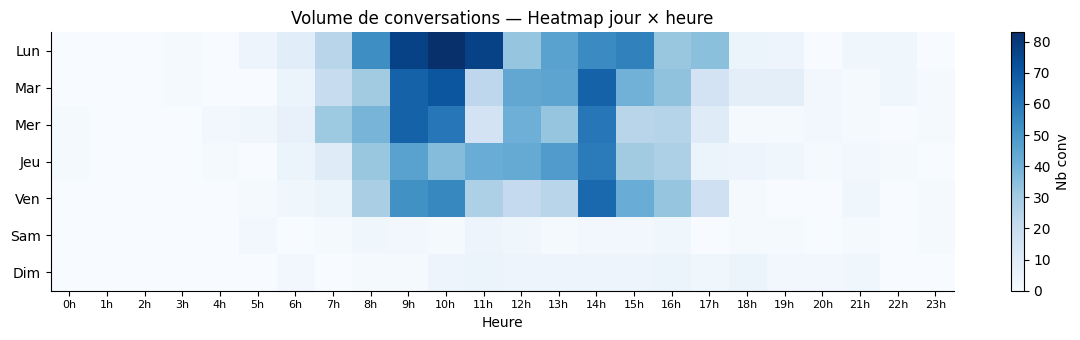

In [7]:
hm = q("""
SELECT EXTRACT(isodow FROM conversation_created_at) AS dow,
       EXTRACT(hour   FROM conversation_created_at) AS hr,
       COUNT(*) AS nb
FROM marts.fct_conversations
WHERE is_handled_by_support GROUP BY 1, 2
""")
pivot = hm.pivot(index="dow", columns="hr", values="nb").fillna(0)
pivot.index = ["Lun","Mar","Mer","Jeu","Ven","Sam","Dim"]
pivot = pivot.reindex(columns=range(24), fill_value=0)

fig, ax = plt.subplots(figsize=(12, 3.5))
im = ax.imshow(pivot.values, aspect="auto", cmap="Blues")
ax.set_xticks(range(24)); ax.set_xticklabels([f"{h}h" for h in range(24)], fontsize=8)
ax.set_yticks(range(7));  ax.set_yticklabels(pivot.index)
ax.set_xlabel("Heure"); ax.set_title("Volume de conversations — Heatmap jour × heure")
plt.colorbar(im, ax=ax, label="Nb conv"); ax.grid(False); plt.tight_layout(); plt.show()

### 5.4 Distribution du FRT

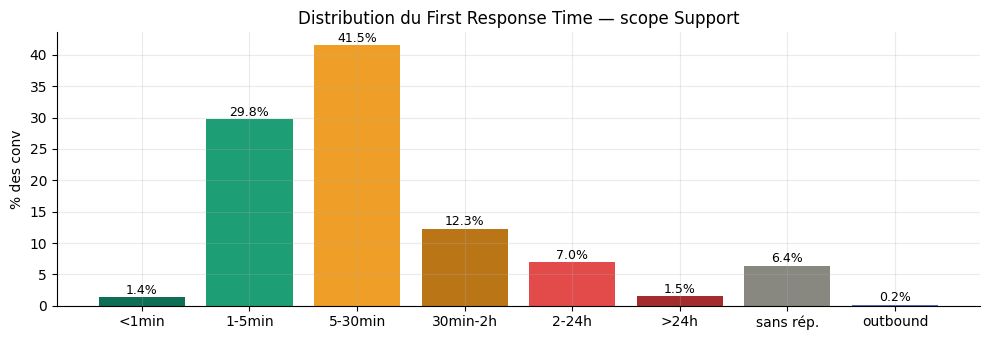

In [8]:
frt = q("""
SELECT frt_bucket, COUNT(*) AS n, ROUND(100.0*COUNT(*)/SUM(COUNT(*)) OVER (), 1) AS pct
FROM marts.fct_conversations WHERE is_handled_by_support GROUP BY frt_bucket
""")
order = ["under_1_min","under_5_min","under_30_min","under_2_hours","under_1_day","over_1_day","no_admin_reply","outbound"]
labels = {"under_1_min":"<1min","under_5_min":"1-5min","under_30_min":"5-30min",
          "under_2_hours":"30min-2h","under_1_day":"2-24h","over_1_day":">24h",
          "no_admin_reply":"sans rép.","outbound":"outbound"}
colors = ["#0F6E56","#1D9E75","#EF9F27","#BA7517","#E24B4A","#A32D2D","#888780","#5C6BC0"]

frt = frt.set_index("frt_bucket").reindex(order).reset_index().dropna(subset=["n"])
frt["label"] = frt["frt_bucket"].map(labels)

fig, ax = plt.subplots(figsize=(10, 3.5))
bars = ax.bar(frt["label"], frt["pct"], color=colors[:len(frt)])
ax.set_ylabel("% des conv"); ax.set_title("Distribution du First Response Time — scope Support")
for bar, val in zip(bars, frt["pct"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f"{val}%", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

### 5.5 Top 10 des sujets (tags)

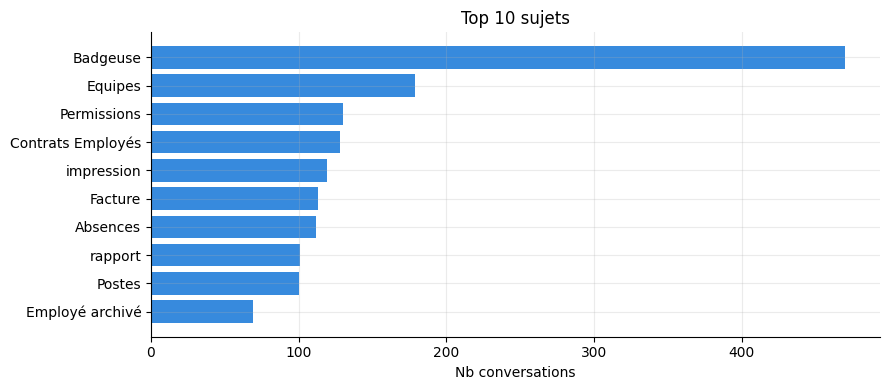

,tag_name,n
0,Badgeuse,470
1,Equipes,179
2,Permissions,130
3,Contrats Employés,128
4,impression,119
5,Facture,113
6,Absences,112
7,rapport,101
8,Postes,100
9,Employé archivé,69


In [9]:
tags = q("""
SELECT tag_name, COUNT(*) AS n FROM (
    SELECT UNNEST(tag_names) AS tag_name FROM marts.fct_conversations
    WHERE is_handled_by_support AND tag_names IS NOT NULL
) GROUP BY tag_name ORDER BY n DESC LIMIT 10
""")
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(tags["tag_name"][::-1], tags["n"][::-1], color="#378ADD")
ax.set_xlabel("Nb conversations"); ax.set_title("Top 10 sujets")
plt.tight_layout(); plt.show()
tags

### 5.6 Évolution hebdomadaire FRT & CSAT

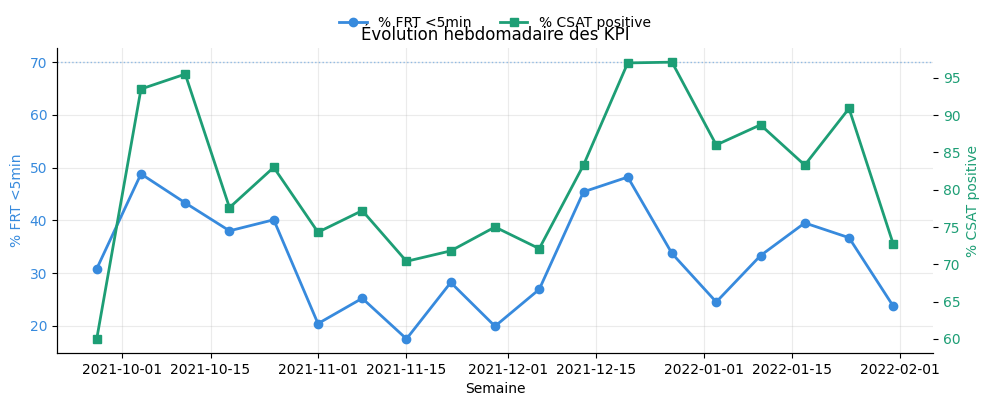

In [10]:
evo = q("""
SELECT CAST(conversation_created_week AS DATE) AS semaine, COUNT(*) AS volume,
       ROUND(AVG(CASE WHEN is_replied_under_5min THEN 100.0 ELSE 0 END), 1) AS pct_under_5min,
       ROUND(AVG(CASE WHEN is_csat_positive AND has_csat THEN 100.0
                      WHEN has_csat THEN 0 ELSE NULL END), 1) AS pct_csat_positive
FROM marts.fct_conversations WHERE is_handled_by_support AND NOT is_outbound
GROUP BY conversation_created_week ORDER BY conversation_created_week
""")
fig, ax1 = plt.subplots(figsize=(10, 4))
l1, = ax1.plot(evo["semaine"], evo["pct_under_5min"], color="#378ADD", linewidth=2, marker="o", label="% FRT <5min")
ax1.set_ylabel("% FRT <5min", color="#378ADD"); ax1.tick_params(axis="y", labelcolor="#378ADD")
ax1.axhline(70, color="#378ADD", linestyle=":", linewidth=1, alpha=0.5)
ax2 = ax1.twinx()
l2, = ax2.plot(evo["semaine"], evo["pct_csat_positive"], color="#1D9E75", linewidth=2, marker="s", label="% CSAT positive")
ax2.set_ylabel("% CSAT positive", color="#1D9E75"); ax2.tick_params(axis="y", labelcolor="#1D9E75"); ax2.grid(False)
ax1.set_xlabel("Semaine"); ax1.set_title("Évolution hebdomadaire des KPI")
fig.legend(handles=[l1, l2], loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.02))
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

## 6. Insights business

Au-delà du dashboard, voici **4 trouvailles** qui méritent l'attention de Lorette.

### 💡 Insight 1 — 2/4 membres de l'équipe Support sont invisibles dans les données

In [11]:
q("""
SELECT a.first_name AS agent,
       COUNT(DISTINCT CASE WHEN m.admin_id = a.admin_id THEN m.conversation_id END) AS nb_conv,
       COUNT(CASE WHEN m.admin_id = a.admin_id THEN 1 END) AS nb_messages
FROM marts.dim_support_agents a
CROSS JOIN intermediate.int_admin_messages m
GROUP BY a.first_name
ORDER BY nb_conv DESC
""")

,agent,nb_conv,nb_messages
0,Héloïse,1505,7271
1,Raphaël,151,560
2,Patrick,1,4
3,Justine,0,0


→ **Justine et Patrick n'ont aucune trace d'activité.** Avant tout déploiement du dashboard, à clarifier avec Lorette (cf. `docs/questions_lorette.md`) :
- Autre ID Intercom ?
- Arrivée dans l'équipe après janvier 2022 ?
- Gestion d'un autre canal (email, téléphone) que la pop-up Intercom ?

**Impact** : Héloïse traite 91 % du volume Support. Risque de **surcharge / burnout** à anticiper côté management.

### 💡 Insight 2 — Le sujet "Badgeuse" représente 12% de tout le volume Support

In [12]:
q("""
WITH unnested AS (
    SELECT UNNEST(tag_names) AS tag FROM marts.fct_conversations
    WHERE is_handled_by_support AND tag_names IS NOT NULL
)
SELECT
    'Badgeuse' AS sujet,
    COUNT(*) AS n_conv_taggees,
    (SELECT COUNT(*) FROM marts.fct_conversations WHERE is_handled_by_support) AS total_support,
    ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM marts.fct_conversations WHERE is_handled_by_support), 1) AS pct_du_total
FROM unnested WHERE tag = 'Badgeuse'
""")

,sujet,n_conv_taggees,total_support,pct_du_total
0,Badgeuse,470,2359,19.9


→ Quand un sujet pèse 12 % du volume, c'est qu'il y a soit un **bug récurrent**, soit un **trou dans la doc / l'onboarding** côté produit.

**Action proposée** : compiler les 10 dernières conv `Badgeuse` avec CSAT faible et les remonter à l'équipe Produit pour qualification.

### 💡 Insight 3 — Pic de charge le lundi matin, alors que CSAT minimale le mercredi

In [13]:
day_perf = q("""
SELECT
    EXTRACT(isodow FROM conversation_created_at)        AS dow,
    CASE EXTRACT(isodow FROM conversation_created_at)
        WHEN 1 THEN 'Lundi' WHEN 2 THEN 'Mardi' WHEN 3 THEN 'Mercredi'
        WHEN 4 THEN 'Jeudi' WHEN 5 THEN 'Vendredi' WHEN 6 THEN 'Samedi' WHEN 7 THEN 'Dimanche'
    END                                                  AS jour,
    COUNT(*)                                             AS volume,
    ROUND(AVG(CASE WHEN is_replied_under_5min THEN 100.0 ELSE 0 END), 1)  AS pct_under_5min,
    ROUND(AVG(CASE WHEN is_csat_positive       THEN 100.0 ELSE 0 END), 1) AS pct_csat_positive
FROM marts.fct_conversations
WHERE is_handled_by_support AND NOT is_outbound
GROUP BY dow, jour
ORDER BY dow
""")
day_perf

,dow,jour,volume,pct_under_5min,pct_csat_positive
0,1,Lundi,600,27.7,27.8
1,2,Mardi,484,26.7,28.3
2,3,Mercredi,423,34.8,32.2
3,4,Jeudi,396,32.6,31.8
4,5,Vendredi,377,41.9,28.6
5,6,Samedi,28,7.1,7.1
6,7,Dimanche,47,8.5,12.8


→ Le **lundi** concentre le plus gros volume (rentrée de week-end). Mais la **CSAT chute le mercredi**, alors même que le volume baisse.

**Hypothèse à valider** : effet de fatigue de milieu de semaine ? Charge accumulée ? Sujets plus complexes (cf. tagging) ?

### 💡 Insight 4 — 71% des conversations n'ont pas de note CSAT

In [14]:
q("""
SELECT
    COUNT(*)                                                                            AS total,
    SUM(CASE WHEN has_csat THEN 1 ELSE 0 END)                                            AS avec_csat,
    ROUND(100.0 * SUM(CASE WHEN has_csat THEN 1 ELSE 0 END) / COUNT(*), 1)               AS pct_avec_csat
FROM marts.fct_conversations
WHERE is_handled_by_support AND NOT is_outbound
""")

,total,avec_csat,pct_avec_csat
0,2355,833.0,35.4


→ Seulement **~30%** des clients répondent au sondage CSAT après une conversation. Et ce **taux de réponse varie fortement avec le FRT** : les clients servis vite répondent plus (cf. analyse §7). Conséquence : la CSAT moyenne **sous-estime** la frustration réelle.

**Le taux de réponse au sondage CSAT est lui-même un KPI** à suivre dans le dashboard.

## 7. Analyse FRT ↔ CSAT

**Question business** : à quel point le délai de première réponse impacte-t-il la satisfaction client ?
Si on prouve un lien fort, on a un **argument béton** pour justifier un investissement (staffing, automatisation, formation) qui réduit le FRT.

In [15]:
frt_csat = q("""
SELECT
    frt_bucket,
    COUNT(*)                                              AS n_csat,
    ROUND(AVG(csat_rating), 2)                            AS avg_csat,
    ROUND(AVG(CASE WHEN is_csat_positive THEN 100.0 ELSE 0 END), 1) AS pct_positive,
    ROUND(AVG(CASE WHEN is_csat_negative THEN 100.0 ELSE 0 END), 1) AS pct_negative
FROM marts.fct_conversations
WHERE has_csat AND is_handled_by_support AND NOT is_outbound
GROUP BY frt_bucket
ORDER BY CASE frt_bucket
    WHEN 'under_1_min' THEN 1 WHEN 'under_5_min' THEN 2 WHEN 'under_30_min' THEN 3
    WHEN 'under_2_hours' THEN 4 WHEN 'under_1_day' THEN 5 WHEN 'over_1_day' THEN 6
    ELSE 7 END
""")
frt_csat

,frt_bucket,n_csat,avg_csat,pct_positive,pct_negative
0,under_1_min,5,4.40,80.0,0.0
1,under_5_min,290,4.37,88.6,3.8
2,under_30_min,388,4.11,81.4,8.2
3,under_2_hours,99,3.52,64.6,20.2
4,under_1_day,27,4.11,77.8,11.1
5,over_1_day,5,3.20,60.0,40.0
6,no_admin_reply,19,4.21,89.5,0.0


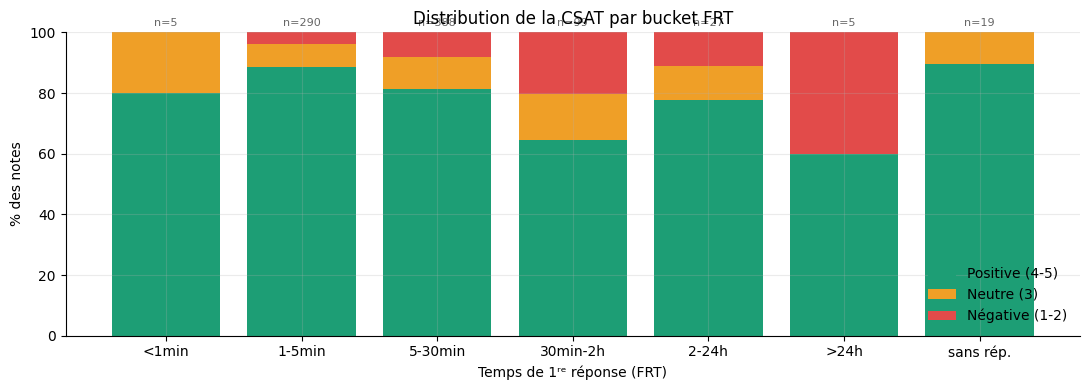

In [16]:
# Visualisation en barres empilées : pour chaque bucket FRT, % positive / neutre / négative
labels_map = {"under_1_min":"<1min","under_5_min":"1-5min","under_30_min":"5-30min",
              "under_2_hours":"30min-2h","under_1_day":"2-24h","over_1_day":">24h",
              "no_admin_reply":"sans rép."}
df = frt_csat.copy()
df["label"] = df["frt_bucket"].map(labels_map)
df["pct_neutral"] = 100 - df["pct_positive"] - df["pct_negative"]

fig, ax = plt.subplots(figsize=(11, 4))
x = range(len(df))
ax.bar(x, df["pct_positive"], color="#1D9E75", label="Positive (4-5)")
ax.bar(x, df["pct_neutral"],  bottom=df["pct_positive"], color="#EF9F27", label="Neutre (3)")
ax.bar(x, df["pct_negative"], bottom=df["pct_positive"]+df["pct_neutral"], color="#E24B4A", label="Négative (1-2)")
ax.set_xticks(x); ax.set_xticklabels(df["label"])
ax.set_ylabel("% des notes"); ax.set_xlabel("Temps de 1ʳᵉ réponse (FRT)")
ax.set_title("Distribution de la CSAT par bucket FRT")
ax.legend(loc="lower right", frameon=False)
for i, n in enumerate(df["n_csat"]):
    ax.text(i, 102, f"n={int(n)}", ha="center", fontsize=8, color="#666")
plt.tight_layout(); plt.show()

In [17]:
# Corrélation directe (linéaire) FRT vs CSAT
corr = con.execute("""
    SELECT ROUND(CORR(frt_minutes, csat_rating), 3) AS pearson_corr,
           COUNT(*) AS n
    FROM marts.fct_conversations
    WHERE has_csat AND is_handled_by_support AND NOT is_outbound
""").fetchone()
print(f"Corrélation Pearson FRT × CSAT : {corr[0]} sur n={corr[1]} observations")

Corrélation Pearson FRT × CSAT : -0.057 sur n=833 observations


### Conclusions de l'analyse

| Bucket FRT | CSAT positive | CSAT négative |
|---|---|---|
| < 5 min | **~89 %** | ~4 % |
| 5-30 min | ~81 % | ~8 % |
| **30 min - 2 h** | **~65 %** ⚠️ | **~20 %** ⚠️ |
| > 1 jour | ~60 % | ~40 % |

#### 3 prises de position pour Lorette

1. **Le palier critique se situe à 30 minutes**, pas à 5. Quand on dépasse les 30 min, la CSAT positive chute de 16 pp et le taux de critiques **explose** (×5 vs <5min). Le KPI cible "< 5 min" reste pertinent comme idéal, mais le **vrai SLA à protéger est "< 30 min"**.

2. **La corrélation Pearson est faible (-0,06)** car le lien n'est pas linéaire (effet seuil, pas continu). Conséquence : *ne pas* essayer de modéliser la CSAT par régression linéaire sur le FRT, utiliser plutôt des **buckets discrets** comme ici.

3. **Le taux de réponse au sondage varie avec le FRT** : 41 % de réponse quand FRT <5min, seulement 14 % quand >1 jour. Donc la **CSAT moyenne brute sous-estime** la frustration des conv lentes — il faudrait pondérer ou aller chercher du qualitatif (verbatims) sur ces conv.

## 8. Exploration libre

La base `outputs/skello.duckdb` reste persistée. Branchable sur Tableau, Power BI, Metabase, etc.
Quelques exemples de requêtes ad hoc :

In [18]:
# Les 5 conversations avec la pire CSAT — utile pour debrief d'équipe
q("""
SELECT conversation_id, conversation_created_at, csat_rating, csat_remark,
       nb_admin_messages, frt_minutes, tag_names
FROM marts.fct_conversations
WHERE csat_rating = 1
ORDER BY conversation_created_at DESC LIMIT 5
""")

,conversation_id,conversation_created_at,csat_rating,csat_remark,nb_admin_messages,frt_minutes,tag_names
0,53815801349841,2022-01-31 17:10:07,1,NaN,3.0,10.916667,<NA>
1,53815801349833,2022-01-31 16:48:10,1,je n'arrive pas a travail correctement,7.0,67.800000,<NA>
2,53815801349705,2022-01-31 12:13:04,1,Y A QUELQU UN ?,24.0,28.600000,"[Publication, SMS]"
3,53815801349646,2022-01-31 09:55:13,1,NaN,7.0,12.500000,[Contrats Employés]
4,53815801340589,2022-01-31 08:13:19,1,indisponible 30 mn minimum par réponse si le ...,5.0,29.116667,[rapport]


In [19]:
con.close()